In [ ]:
!pip install opencv-python
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

from google.colab import files
uploaded = files.upload()

# Load image
img_path = list(uploaded.keys())[0]

# Read the image properly
image = cv2.imread(img_path)

# Check if image is loaded successfully and convert it from BGR to RGB
if image is None:
  print("Image loading failed")
else:
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)



Saving CHNCXR_0329_1.png to CHNCXR_0329_1.png


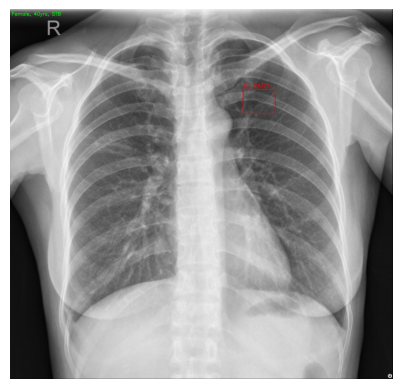

In [ ]:
# Adding TB patch box and label (TB PATCH)
x, y, w_box, h_box = 1450, 500, 200, 150
image_with_patch = image.copy()
cv2.rectangle(image_with_patch, (x, y), (x + w_box, y + h_box), (255, 0, 0), 4)
cv2.putText(image_with_patch, "TB PATCH", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 2)
cv2.putText(image_with_patch, "Female, 40yrs, STB", (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
plt.imshow(image_with_patch)
plt.axis("off")
plt.show()

In [ ]:
# Creating rotated frames
os.makedirs("frames", exist_ok=True)

h, w = image.shape[:2]
for angle in range(-30,31,2):
  M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
  rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR)
  cv2.imwrite(f"frames/frame_{angle+30:03d}.png", cv2.cvtColor(rotated, cv2.COLOR_RGB2BGR))

print ("Rotated frames saved in /frames folder")

Rotated frames saved in /frames folder


In [ ]:
# Creating GIF from rotated frames
!pip install imageio
import imageio.v2 as imageio
import glob

frames = []
frame_files = sorted(glob.glob("frames/*.png"))
for file in frame_files:
  frames.append(imageio.imread(file))

imageio.mimsave("chest_rotation.gif", frames, duration = 0.05)
print("GIF created : chest_rotation.gif")

GIF created : chest_rotation.gif


In [ ]:
# Downloading GIF
from google.colab import files
files.download("chest_rotation.gif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>